🛍 Scenario: Fashion Product Image Classifier
You are working as an AI Engineer for an e-commerce company.
The company wants to automatically classify clothing products from images into categories such as:
T-shirt
Trouser
Pullover
Dress
Coat
Sandal
Shirt
Sneaker
Bag
Ankle boot
The dataset contains 28×28 grayscale images of fashion items.
Your goal is to build a Convolutional Neural Network (CNN) that can classify these fashion products correctly.

Task 1 — Dataset Exploration
Load the Fashion-MNIST dataset and perform basic inspection.
Students must:
Load dataset using TensorFlow/Keras
Print:
Number of training images
Number of testing images
Display 10 random images with their labels
Goal:

Understand the dataset visually.
Task 2 — Data Preprocessing
Prepare the dataset for CNN training.
Students must:
Normalize pixel values (0–255 → 0–1)
Reshape images to CNN format
Expected shape:
(28, 28, 1)
Also convert labels to one-hot encoding.

Task 3 — Visualize Class Distribution
Students must:
Count number of images in each class
Plot bar chart of class distribution
Goal:

Check whether the dataset is balanced.


In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
print("Number of training images:", x_train.shape[0])
print("Number of testing images:", x_test.shape[0])
print("Image shape:", x_train[0].shape)

Number of training images: 60000
Number of testing images: 10000
Image shape: (28, 28)


### Display 10 Random Images with Labels

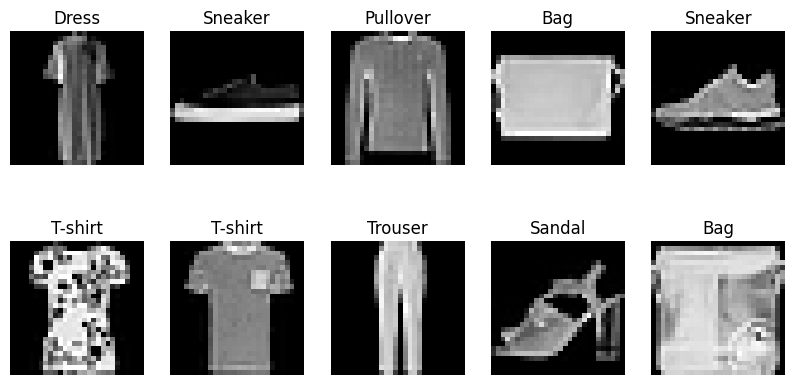

In [3]:
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10,5))

for i in range(10):
    index = np.random.randint(0, len(x_train))

    plt.subplot(2,5,i+1)
    plt.imshow(x_train[index], cmap='gray')
    plt.title(class_names[y_train[index]])
    plt.axis('off')

plt.show()

## Data Preprocessing
### 1. Normalize Pixel Values (0–255 → 0–1)

In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0

### 2.Reshape Images for CNN

### CNN expects (height, width, channels).

In [5]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

Training shape: (60000, 28, 28, 1)
Testing shape: (10000, 28, 28, 1)


### 3. Convert Labels to One-Hot Encoding

In [6]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Label shape:", y_train.shape)

Label shape: (60000, 10)


## Visualize Class Distribution

### 1. Count Images in Each Class

In [7]:
labels = np.argmax(y_train, axis=1)

class_counts = np.bincount(labels)

print("Images per class:", class_counts)

Images per class: [6000 6000 6000 6000 6000 6000 6000 6000 6000 6000]


### 2. Plot Bar Chart of Class Distribution

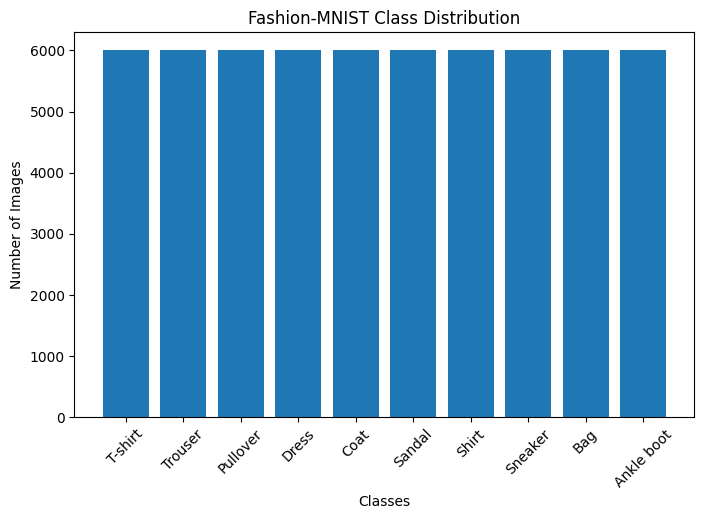

In [8]:
plt.figure(figsize=(8,5))

plt.bar(class_names, class_counts)

plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Fashion-MNIST Class Distribution")

plt.xticks(rotation=45)

plt.show()

Task 4 — Build First CNN Architecture
Students must implement a CNN with this architecture:
Input (28x28x1)
↓
Conv2D (32 filters, 3x3)
↓
ReLU
↓
MaxPooling (2x2)
↓
Conv2D (64 filters, 3x3)
↓
ReLU
↓
MaxPooling (2x2)
↓
Flatten
↓
Dense (128)
↓
Softmax (10)
Goal:
Understand basic CNN architecture.

## Task 4 — Build First CNN Architecture

#### Build a Convolutional Neural Network (CNN) to classify Fashion-MNIST images.

#### Input image size:

28×28×1

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

#### Build CNN Model

In [10]:
model = Sequential([

    # Input Layer
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),

    # Max Pooling
    MaxPooling2D(pool_size=(2,2)),

    # Second Convolution Layer
    Conv2D(64, (3,3), activation='relu'),

    # Max Pooling
    MaxPooling2D(pool_size=(2,2)),

    # Flatten Layer
    Flatten(),

    # Fully Connected Layer
    Dense(128, activation='relu'),

    # Output Layer
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

#### Compile the Model

We configure how the model will learn.

In [12]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

#### Train the cnn model

In [13]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 48s 62ms/step - accuracy: 0.7386 - loss: 0.7405 - val_accuracy: 0.8642 - val_loss: 0.3780
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 80s 60ms/step - accuracy: 0.8777 - loss: 0.3454 - val_accuracy: 0.8794 - val_loss: 0.3283
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 83s 61ms/step - accuracy: 0.8910 - loss: 0.2978 - val_accuracy: 0.8957 - val_loss: 0.2924
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 46s 61ms/step - accuracy: 0.9016 - loss: 0.2682 - val_accuracy: 0.8955 - val_loss: 0.2902
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 44s 58ms/step - accuracy: 0.9113 - loss: 0.2377 - val_accuracy: 0.9071 - val_loss: 0.2547
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 57ms/step - accuracy: 0.9221 - loss: 0.2127 - val_accuracy: 0.9042 - val_loss: 0.2626
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 83s 58ms/step - accuracy: 0.9268 - loss: 0.1972 - val_accuracy: 0.9112 - val_loss: 0.2431
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 57ms/step - accuracy: 0.9337 - loss: 0.1763 - 

#### Evaluate Model on Test Data

In [14]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9045 - loss: 0.2770
Test Accuracy: 0.906000018119812


# Task 6 — Train the Model
Train the CNN with:
Epochs = 10
Batch size = 64
Validation split = 20%
Students must:
Plot training accuracy vs validation accuracy
Plot training loss vs validation loss

### Plot Training Accuracy vs Validation Accuracy

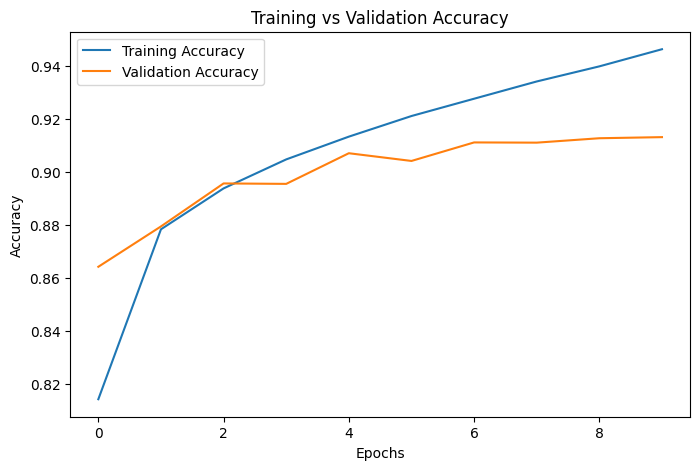

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

### Plot training loss vs validation loss

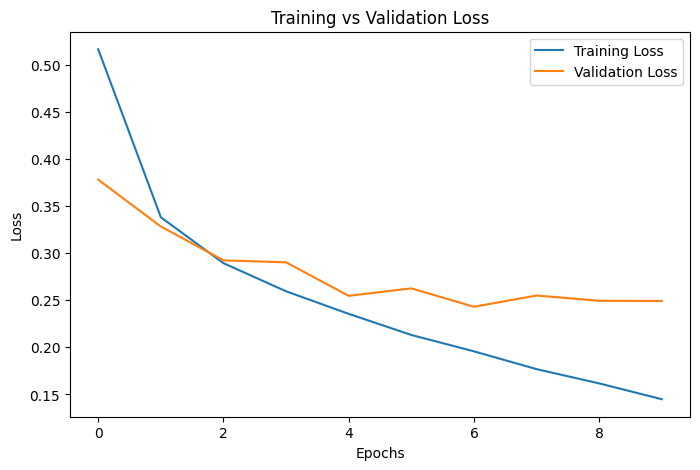

In [16]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

# Task 7 — Model Evaluation
#Evaluate model performance on test dataset.
Students must print:
Test accuracy
Test loss
Then display 5 test images with predictions.
Goal:
Understand how models generalize to unseen data.

#### Evaluate Model on Test Dataset

In [17]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9045 - loss: 0.2770
Test Loss: 0.26756855845451355
Test Accuracy: 0.906000018119812


#### Predict Labels for Test Images

In [18]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


#### Convert Probabilities to Class Labels

In [19]:
predicted_classes = np.argmax(predictions, axis=1)

true_classes = np.argmax(y_test, axis=1)

#### Display 5 Test Images with Predictions

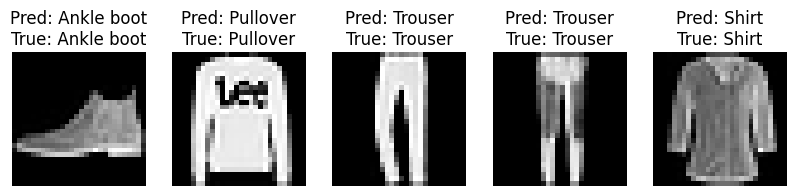

In [20]:
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10,5))

for i in range(5):

    plt.subplot(1,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')

    predicted_label = class_names[predicted_classes[i]]
    true_label = class_names[true_classes[i]]

    plt.title(f"Pred: {predicted_label}\nTrue: {true_label}")
    plt.axis('off')

plt.show()

### Task 8 — Confusion Matrix Analysis

### Convert One-Hot Labels Back to Class Labels

Earlier we converted labels to one-hot encoding, but confusion matrix requires class numbers.

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [22]:
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(predictions, axis=1)

### Generate Confusion Matrix

In [23]:
cm = confusion_matrix(y_true, y_pred)

print(cm)

[[808   0  18  17   3   1 147   0   6   0]
 [  1 983   1   8   2   0   5   0   0   0]
 [ 13   0 827  10  67   0  82   0   1   0]
 [ 12  15   8 900  36   0  29   0   0   0]
 [  0   1  19  16 899   0  64   0   1   0]
 [  0   0   0   1   0 984   0   9   0   6]
 [ 82   1  51  22  72   0 768   0   4   0]
 [  0   0   0   0   0  22   0 960   0  18]
 [  2   1   3   4   2   2   7   4 975   0]
 [  1   0   0   0   0   5   0  38   0 956]]


### Define Class Names

In [24]:
class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

### Visualize Confusion Matrix using Heatmap

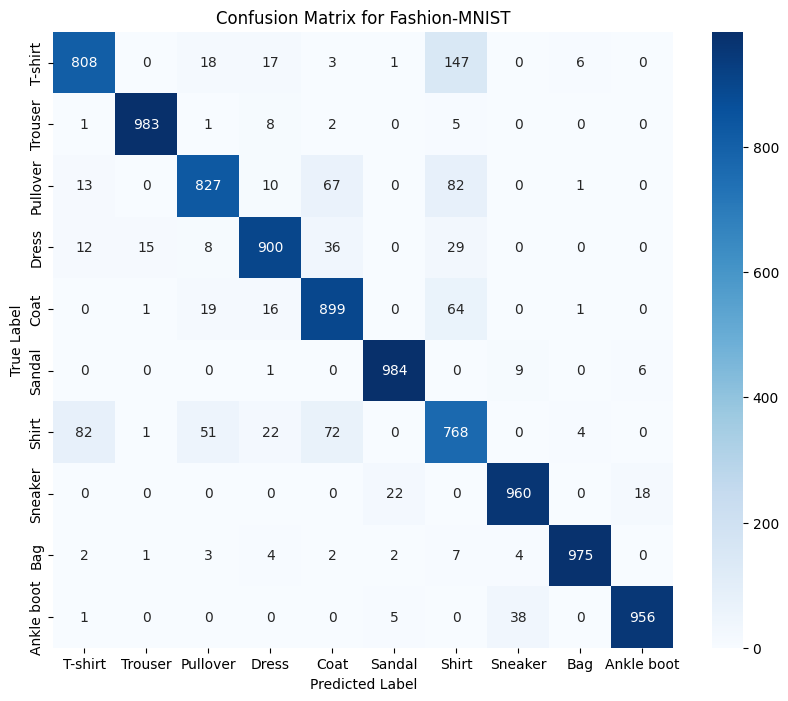

In [25]:
plt.figure(figsize=(10,8))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Fashion-MNIST")

plt.show()

## Final Project Pipeline
- Task 1 → Dataset Exploration
- Task 2 → Data Preprocessing
- Task 3 → Class Distribution
- Task 4 → Build CNN
- Task 5 → Compile Model
- Task 6 → Train Model
- Task 7 → Model Evaluation
- Task 8 → Confusion Matrix Analysis

### Task 9 — Improve the CNN Architecture

In [28]:
from tensorflow.keras.layers import Dropout
model2 = tf.keras.models.Sequential([

    # First Convolution Block
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    # Second Convolution Block
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    # Flatten Layer
    Flatten(),

    # Fully Connected Layer
    Dense(128, activation='relu'),

    # Dropout to reduce overfitting
    Dropout(0.5),

    # Output Layer
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
#Train Model 2
history2 = model2.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 101s 128ms/step - accuracy: 0.6874 - loss: 0.8644 - val_accuracy: 0.8588 - val_loss: 0.3679
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 95s 126ms/step - accuracy: 0.8524 - loss: 0.4101 - val_accuracy: 0.8825 - val_loss: 0.3050
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 142s 126ms/step - accuracy: 0.8806 - loss: 0.3315 - val_accuracy: 0.9003 - val_loss: 0.2684
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 143s 128ms/step - accuracy: 0.8958 - loss: 0.2885 - val_accuracy: 0.9082 - val_loss: 0.2482
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 107s 142ms/step - accuracy: 0.9043 - loss: 0.2695 - val_accuracy: 0.9118 - val_loss: 0.2405
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 107s 143ms/step - accuracy: 0.9146 - loss: 0.2394 - val_accuracy: 0.9095 - val_loss: 0.2457
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 107s 143ms/step - accuracy: 0.9192 - loss: 0.2209 - val_accuracy: 0.9178 - val_loss: 0.2226
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 141s 142ms/step - accuracy: 0.9225 - 

In [33]:
test_loss2, test_accuracy2 = model2.evaluate(x_test, y_test)

print("Model 2 Test Accuracy:", test_accuracy2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.9173 - loss: 0.2615
Model 2 Test Accuracy: 0.9153000116348267


In [34]:
print("Model 1 Accuracy:", test_accuracy)
print("Model 2 Accuracy:", test_accuracy2)

Model 1 Accuracy: 0.906000018119812
Model 2 Accuracy: 0.9153000116348267


## Task 10 — Misclassification Analysis
Students must:
Identify 5 wrongly predicted images
Display:
Actual label
Predicted label
Then explain:
Why might the model confuse these classes?
Goal:
Develop model debugging skills.


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Total misclassified images: 940


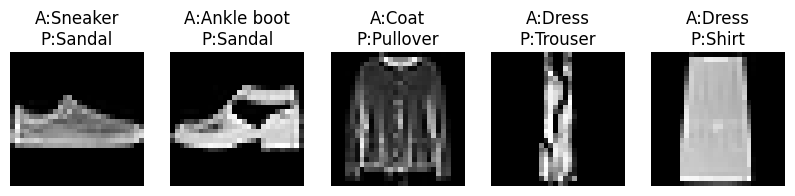

In [35]:
predictions = model.predict(x_test)

y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1)

#Find Misclassified Images
misclassified = np.where(y_pred != y_true)[0]

print("Total misclassified images:", len(misclassified))
#Display 5 Misclassified Images
plt.figure(figsize=(10,5))

for i in range(5):
    idx = misclassified[i]

    plt.subplot(1,5,i+1)
    plt.imshow(x_test[idx].reshape(28,28), cmap='gray')

    actual = class_names[y_true[idx]]
    predicted = class_names[y_pred[idx]]

    plt.title(f"A:{actual}\nP:{predicted}")
    plt.axis('off')

plt.show()

Task 11 — Feature Map Visualization
Students must:
Extract intermediate CNN layer outputs
Visualize feature maps for one image
Goal:
Understand what CNN learns internally.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


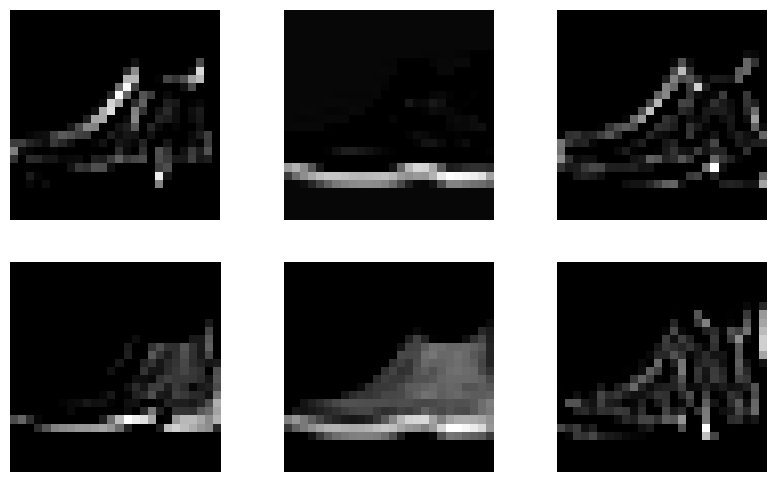

In [37]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input

# Define a symbolic input tensor with the expected shape
input_tensor = Input(shape=(28, 28, 1))

# Build a new model that takes the input_tensor and outputs the desired intermediate layers
extracted_outputs = []
x = input_tensor
for i, layer in enumerate(model.layers):
    x = layer(x)
    if i < 4: # Get outputs of the first 4 layers
        extracted_outputs.append(x)

feature_model = Model(inputs=input_tensor, outputs=extracted_outputs)

# Select One Image
test_image = x_test[0].reshape(1,28,28,1)

# Generate Feature Maps
feature_maps = feature_model.predict(test_image)

# Visualize Feature Maps (from the first convolutional layer, which is feature_maps[0])
feature_map_to_display = feature_maps[0]

plt.figure(figsize=(10,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(feature_map_to_display[0,:,:,i], cmap='gray')
    plt.axis('off')

plt.show()

## Task 12 — Build Simple Prediction Interface
- Students must write code that:
- Takes a random test image
- Predicts class
- Displays predicted label with probability

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


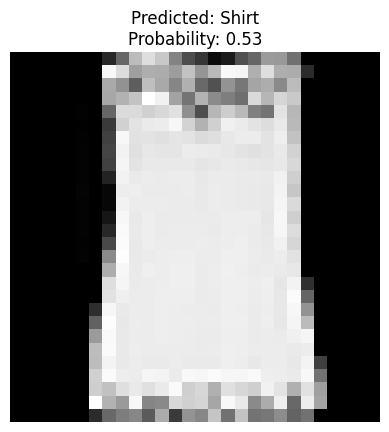

In [38]:
import random

index = random.randint(0, len(x_test)-1)

image = x_test[index]
true_label = class_names[np.argmax(y_test[index])]
#Predict Image Class
prediction = model.predict(image.reshape(1,28,28,1))

predicted_class = np.argmax(prediction)
predicted_label = class_names[predicted_class]

probability = prediction[0][predicted_class]
#Display Prediction
plt.imshow(image.reshape(28,28), cmap='gray')

plt.title(f"Predicted: {predicted_label}\nProbability: {probability:.2f}")

plt.axis('off')
plt.show()